# Analyzing French monthly birth level (1946–2025)

**A linear regression study applied to birth rates in Metropolitan France for prediction purposes**

## Objective

France records births monthly, and the series has two structures: a slow-moving level
(post-war baby boom, the drop of the mid-1970s, post-2015 decline...) and a repeating seasonal
pattern. This project asks two questions:

1. How large is the seasonal effect of each month? Is it stable
   across the decades?
2. How well does a linear trend + seasonality model predict the next twenty years ?


## Data

Monthly live births in metropolitan France, January 1946 to December 2025, published by INSEE.
Download the CSV from <https://www.insee.fr/fr/statistiques/serie/000436391>.

## Model

For month $t = 1,\dots,n$, with period $T = 12$ and $r(t) = 1 + ((t-1) \bmod T)$ the month index,

$$X_t = \gamma_0 + \gamma_1 t + s_{r(t)} + \sigma\varepsilon_t,
\qquad \varepsilon_t \overset{\text{iid}}{\sim} \mathcal N(0,1).$$

- $X_t$ the number of live births recorded in month $t$.
- $r(t) = 1 + ((t-1) \bmod T)$ the calendar month of $t$, as a number from 1 (January) to 12
  (December). It is the only non-linear ingredient, and it is deterministic: no parameter is being
  estimated here, it is simply how the clock wraps around.
- $\gamma_1$ is the change in monthly births from one month to
  the next, so $12\gamma_1$ reads as a change per year.
- $\gamma_0$ is the level extrapolated back to $t=0$.
- $s_{r(t)}$ the seasonal effect of the calendar month, in births. It says how far a given month
  sits above or below the trend line, and it is assumed to be the same in every year of the window:
  every January shares the value $s_1$, and so on...

The twelve seasonal effects need a constraint. Adding a constant $c$ to every $s_j$ while
subtracting $c$ from $\gamma_0$ leaves every $X_t$ unchanged, so without a normalisation the
parameters are not identifiable. Imposing

$$\sum_{j=1}^{T} s_j = 0$$

fixes this and gives the $s_j$ their natural reading: seasonal deviations from the trend.


Collecting the free parameters into
$\beta = (\gamma_0, \gamma_1, s_1, \dots, s_{T-1})^\top$, the model becomes
$X = Z\beta + \sigma\varepsilon$ with $Z = [\,V \mid C\,] \in \mathbb R^{n \times (T+1)}$, where

$$V_t = (1, t), \qquad C_{t,j} = \mathbf 1_{\{r(t)=j\}} - \mathbf 1_{\{r(t)=T\}}, \quad j = 1,\dots,T-1.$$


$Z$ has full rank as soon as $n \ge T+1$.

## Methods

| Quantity | Estimator | Exact law under the Gaussian model |
|---|---|---|
| $\beta$ | $\hat\beta = (Z^\top Z)^{-1}Z^\top X$ | $\mathcal N_p\big(\beta, \sigma^2 (Z^\top Z)^{-1}\big)$ |
| $\sigma^2$ | $\hat\sigma^2 = \lVert X - Z\hat\beta\rVert^2/(n-p)$ | $(n-p)\hat\sigma^2/\sigma^2 \sim \chi^2_{n-p}$, independent of $\hat\beta$ |
| $x^\top\beta$ | $\big(x^\top\hat\beta - x^\top\beta\big)\big/\hat\sigma\sqrt{x^\top(Z^\top Z)^{-1}x}$ | Student $\mathcal T_{n-p}$ |

$\hat\beta$ is unbiased and, by the Gauss–Markov argument, has the smallest variance among linear
unbiased estimators.


Everything below is computed directly from these formulas

## Estimation strategy

The model cannot hold over eighty years: the trend is not a single straight line and the seasonal
shape drifts. So it is fitted on **rolling 20-year windows** ($n = 240$) starting every ten years:
1946–1965, 1956–1975, …, 2006–2025. Each window is a separate model. Windows whose following twenty
years are also observed give genuinely out-of-sample data for the prediction intervals.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_PATH = "data/valeurs_mensuelles.csv"
PERIOD = 12                  # T
N_WINDOW = 240               # 20 years of monthly data
N_PARAMS = PERIOD + 1        # p
ALPHA = 0.05

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
PARAM_NAMES = ["intercept", "trend"] + ["s_" + str(i) for i in range(1, PERIOD)]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Data

The INSEE export is a semicolon-separated file with a few metadata lines on top and the
observations in reverse chronological order, one `YYYY-MM;value;quality_code` row per month.

In [30]:
def load_insee_series(path):
    """Return a chronologically sorted Series of monthly births indexed by period string."""
    raw = pd.read_csv(path, sep=";", header=None, dtype=str,
                      engine="python", on_bad_lines="skip")
    is_obs = raw[0].str.fullmatch(r'"?\d{4}-\d{2}"?', na=False)
    obs = raw[is_obs].copy()
    obs[0] = obs[0].str.strip('"')
    obs[1] = obs[1].str.strip('"').str.replace(r"[\s\u202f\xa0]", "", regex=True)
    series = pd.Series(obs[1].astype(float).values, index=obs[0].values)
    return series.sort_index()


births = load_insee_series(DATA_PATH).loc["1946-01":"2025-12"]
assert len(births) == 80 * PERIOD, f"expected 960 monthly observations, got {len(births)}"

years = 1946 + np.arange(len(births)) / PERIOD     # decimal year, for plotting
print(f"{len(births)} observations from {births.index[0]} to {births.index[-1]}")
births.head()

960 observations from 1946-01 to 2025-12


1946-01    64599.0
1946-02    65702.0
1946-03    78294.0
1946-04    76400.0
1946-05    76636.0
dtype: float64

## 2. Series visualisation

Figure 1: raw series with a centred 12-month moving average to strip out seasonal noise
Figure 2: average seasonal shape per decade, each decade normalised by its own mean.

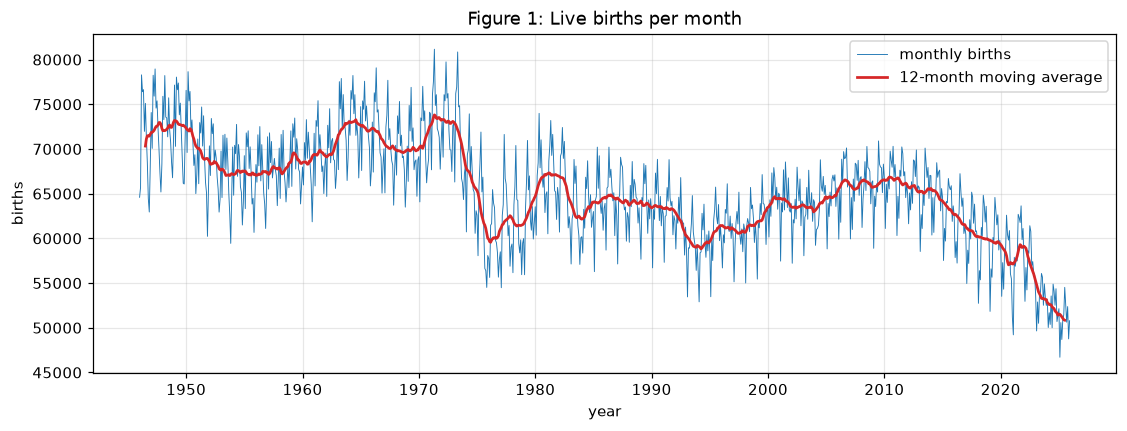

In [31]:
values = births.values
moving_avg = pd.Series(values).rolling(PERIOD, center=True).mean().values

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(years, values, lw=0.6, color="C0", label="monthly births")
ax.plot(years, moving_avg, lw=1.8, color="C3", label="12-month moving average")
ax.set_xlabel("year"), ax.set_ylabel("births")
ax.set_title("Figure 1: Live births per month")
ax.legend()
plt.show()

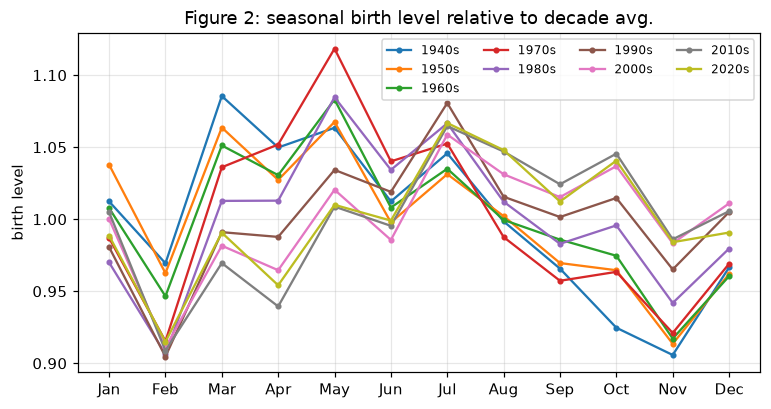

In [32]:
decade = np.array([int(p[:4]) // 10 * 10 for p in births.index])
month = np.array([int(p[5:]) for p in births.index])

fig, ax = plt.subplots(figsize=(8, 4))
for d in np.unique(decade):
    profile = np.array([values[(decade == d) & (month == m)].mean() for m in range(1, 13)])
    ax.plot(range(1, 13), profile / profile.mean(), marker="o", ms=3, label=f"{d}s")
ax.set_xticks(range(1, 13)), ax.set_xticklabels(MONTHS)
ax.set_ylabel("birth level")
ax.set_title("Figure 2: seasonal birth level relative to decade avg.")
ax.legend(ncol=4, fontsize=8)
plt.show()

## 3. The estimators

`design_matrix` builds $Z$, `fit_ols` returns $\hat\beta$, $\hat\sigma^2$ and $(Z^\top Z)^{-1}$.
The solve is done with `np.linalg.solve` on the normal equations.

In [33]:
def design_matrix(t, period=PERIOD):
    """Design matrix of the trend + seasonality model for time indices t (1-based)."""
    t = np.asarray(t, dtype=float)
    r = 1 + (t.astype(int) - 1) % period
    trend_block = np.column_stack([np.ones_like(t), t])
    season_block = np.zeros((len(t), period - 1))
    for j in range(1, period):
        season_block[:, j - 1] = (r == j).astype(float) - (r == period).astype(float)
    return np.hstack([trend_block, season_block])


def fit_ols(x):
    """Least-squares fit of the model on a block of consecutive months."""
    n = len(x)
    Z = design_matrix(np.arange(1, n + 1))
    p = Z.shape[1]
    gram_inv = np.linalg.inv(Z.T @ Z)
    beta = gram_inv @ (Z.T @ x)
    residuals = x - Z @ beta
    sigma2 = residuals @ residuals / (n - p)
    return {"n": n, "p": p, "Z": Z, "gram_inv": gram_inv,
            "beta": beta, "sigma2": sigma2, "residuals": residuals, "x": x}



Since $s_{12}$ is not a coordinate of $\beta$, it is recovered as $-\sum_{j<12} s_j$, and any
statement about it uses $x = (0, 0, -1, \dots, -1)^\top$.

In [34]:
windows = {}
for start in range(1946, 2007, 10):
    offset = (start - 1946) * PERIOD
    windows[start] = fit_ols(values[offset:offset + N_WINDOW])

summary = pd.DataFrame(
    {f"{start}-{start + 19}": np.r_[f["beta"], -f["beta"][2:].sum(), np.sqrt(f["sigma2"])]
     for start, f in windows.items()},
    index=PARAM_NAMES + ["s_12 (implied)", "sigma_hat"]).T
summary.round(0)

,intercept,trend,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12 (implied),sigma_hat
1946-1965,69973.0,-1.0,1645.0,-2820.0,4439.0,2181.0,4802.0,163.0,2532.0,191.0,-1740.0,-2782.0,-5990.0,-2620.0,2642.0
1956-1975,69569.0,2.0,892.0,-3969.0,3574.0,2426.0,6126.0,752.0,2458.0,-398.0,-1831.0,-2219.0,-5540.0,-2272.0,3114.0
1966-1985,71799.0,-41.0,-1178.0,-5625.0,2053.0,2513.0,7001.0,2213.0,3677.0,-260.0,-1940.0,-1632.0,-4909.0,-1914.0,3497.0
1976-1995,64263.0,-10.0,-1929.0,-6065.0,479.0,598.0,5039.0,2251.0,4399.0,621.0,-973.0,13.0,-3417.0,-1017.0,2558.0
1986-2005,62635.0,1.0,-943.0,-5781.0,-419.0,-846.0,2391.0,726.0,4310.0,1189.0,-22.0,1172.0,-2024.0,246.0,2153.0
1996-2015,62040.0,19.0,13.0,-5599.0,-1087.0,-2209.0,1127.0,-497.0,3917.0,1934.0,1027.0,2132.0,-1345.0,587.0,1673.0
2006-2025,69627.0,-68.0,-401.0,-5825.0,-1621.0,-3450.0,632.0,-367.0,3936.0,2837.0,1491.0,2847.0,-642.0,563.0,2088.0


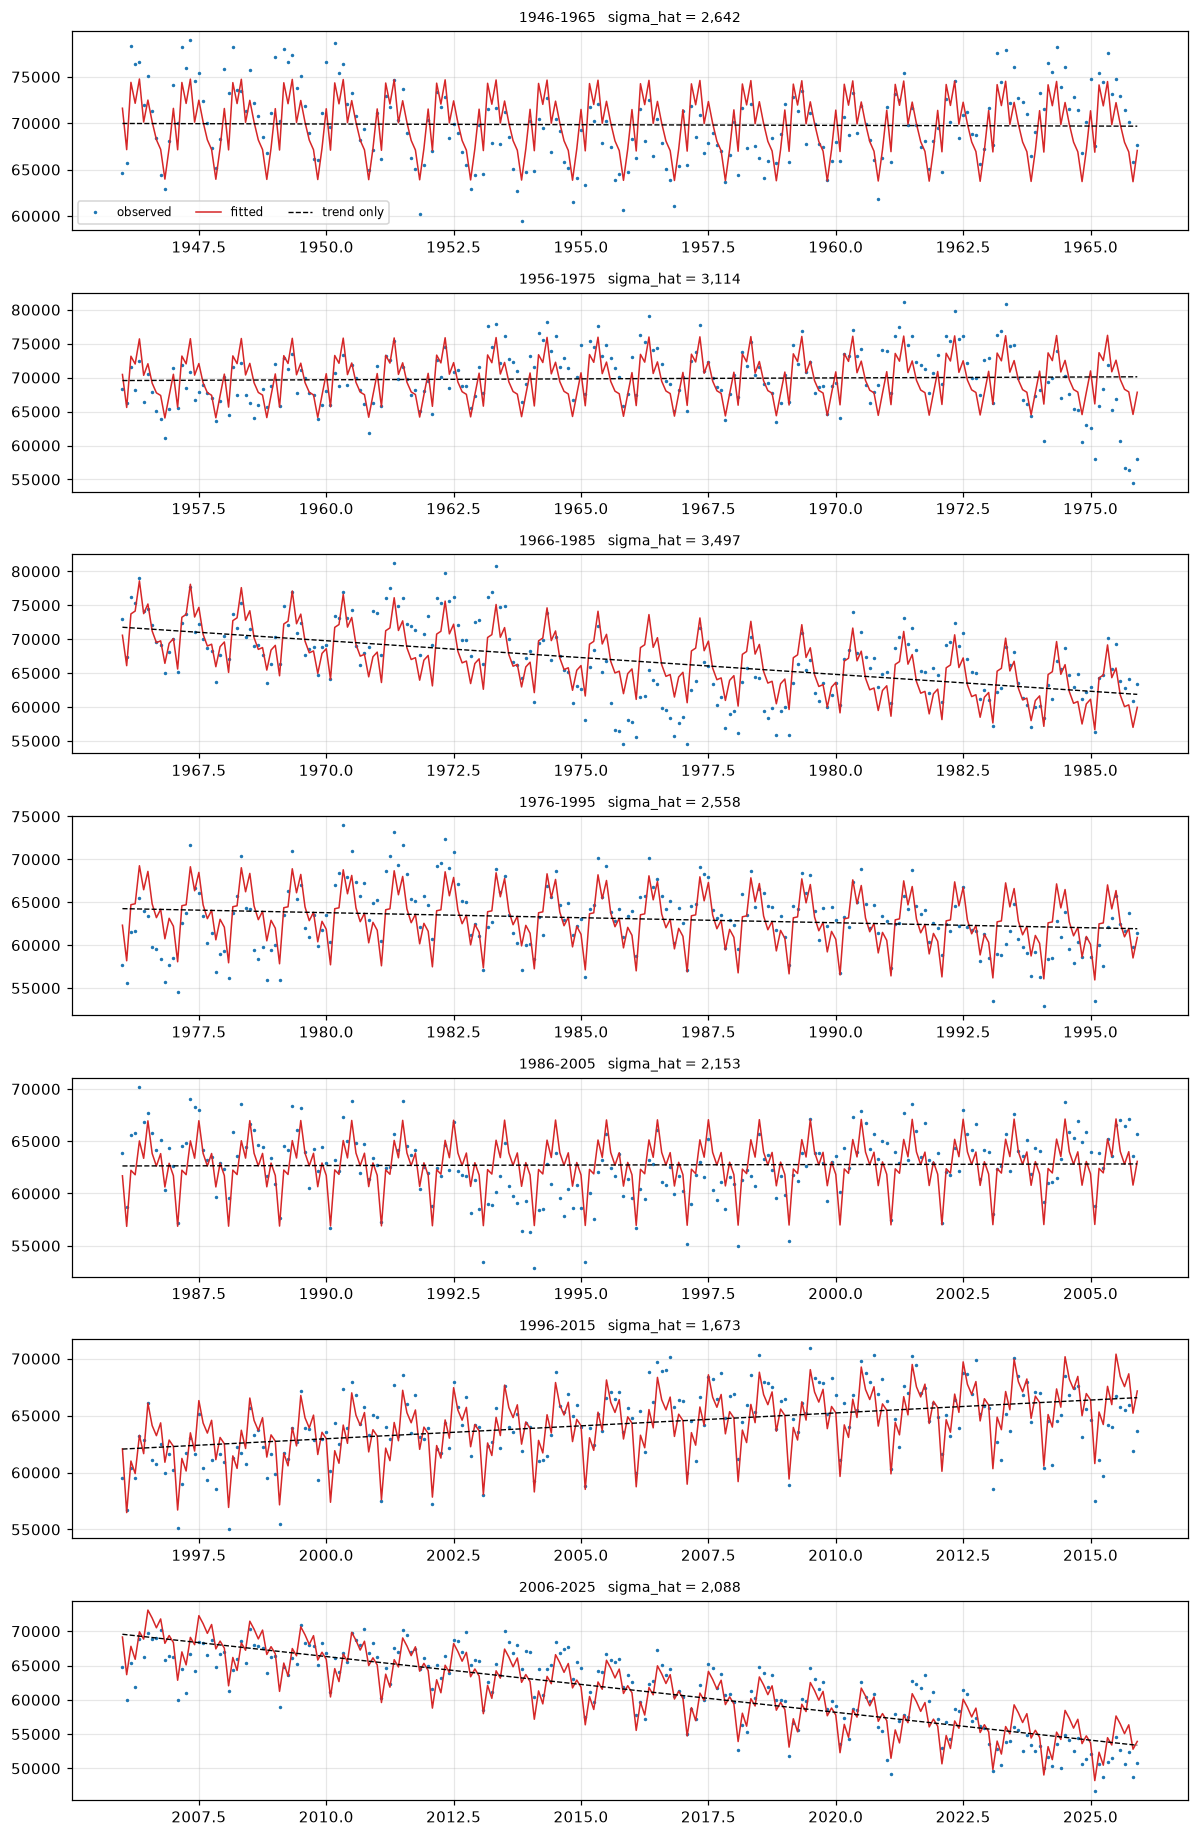

In [35]:
fig, axes = plt.subplots(len(windows), 1, figsize=(11, 2.4 * len(windows)))
for ax, (start, f) in zip(axes, windows.items()):
    t_axis = start + np.arange(N_WINDOW) / PERIOD
    ax.plot(t_axis, f["x"], ".", ms=2.5, color="C0", label="observed")
    ax.plot(t_axis, f["Z"] @ f["beta"], color="C3", lw=1, label="fitted")
    ax.plot(t_axis, f["beta"][0] + f["beta"][1] * np.arange(1, N_WINDOW + 1),
            "--", color="k", lw=0.9, label="trend only")
    ax.set_title(f"{start}-{start + 19}   sigma_hat = {np.sqrt(f['sigma2']):,.0f}", fontsize=9)
axes[0].legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

## 4. Confidence intervals

For a linear functional $x^\top\beta$ the Student pivot gives
$x^\top\hat\beta \pm q_{n-p}(1-\alpha/2)\,\hat\sigma\sqrt{x^\top(Z^\top Z)^{-1}x}$;
for the noise level the $\chi^2$ pivot gives
$\big[(n-p)\hat\sigma^2/\chi^2_{n-p}(1-\alpha/2),\ (n-p)\hat\sigma^2/\chi^2_{n-p}(\alpha/2)\big]$.
Note the inverted quantiles: a large $\chi^2$ quantile produces the *lower* bound on $\sigma^2$.

In [36]:
def confidence_intervals(fit, alpha=ALPHA):
    n, p = fit["n"], fit["p"]
    q = stats.t.ppf(1 - alpha / 2, n - p)
    directions = list(np.eye(p)) + [np.r_[0, 0, -np.ones(PERIOD - 1)]]
    rows = []
    for name, x in zip(PARAM_NAMES + ["s_12"], directions):
        point = x @ fit["beta"]
        half = q * np.sqrt(fit["sigma2"] * x @ fit["gram_inv"] @ x)
        rows.append((name, point, point - half, point + half))
    dof = n - p
    rows.append(("sigma2", fit["sigma2"],
                 dof * fit["sigma2"] / stats.chi2.ppf(1 - alpha / 2, dof),
                 dof * fit["sigma2"] / stats.chi2.ppf(alpha / 2, dof)))
    return pd.DataFrame(rows, columns=["parameter", "estimate", "lower", "upper"]).set_index("parameter")


intervals = {start: confidence_intervals(f) for start, f in windows.items()}
intervals[2006].round(1)

,estimate,lower,upper
parameter,,,
intercept,69626.8,69093.4,70160.2
trend,-67.7,-71.6,-63.9
s_1,-400.6,-1281.8,480.6
s_2,-5825.1,-6706.3,-4944.0
s_3,-1621.2,-2502.3,-740.2
s_4,-3450.1,-4331.1,-2569.0
s_5,632.5,-248.5,1513.5
s_6,-367.0,-1247.9,514.0
s_7,3935.8,3054.9,4816.8


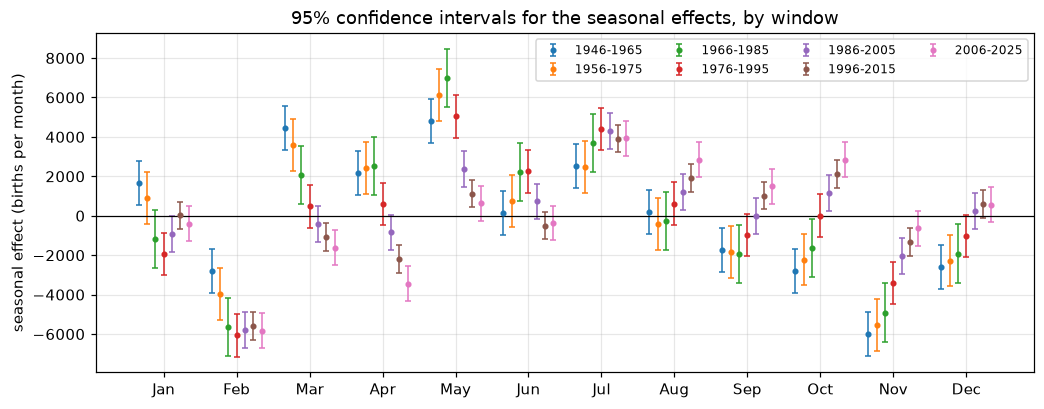

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
width = 0.8 / len(intervals)
for k, (start, table) in enumerate(intervals.items()):
    seasonal = table.loc[[f"s_{j}" for j in range(1, 13)]]
    offsets = np.arange(12) + (k - len(intervals) / 2 + 0.5) * width
    ax.errorbar(offsets, seasonal["estimate"],
                yerr=[seasonal["estimate"] - seasonal["lower"],
                      seasonal["upper"] - seasonal["estimate"]],
                fmt="o", ms=3, capsize=2, lw=1, label=f"{start}-{start + 19}")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(12)), ax.set_xticklabels(MONTHS)
ax.set_ylabel("births per month")
ax.set_title("95% confidence intervals for the seasonal effects, by window")
ax.legend(fontsize=8, ncol=4)
plt.show()

## 5. Out-of-sample prediction

Each window whose following twenty years are observed is used to predict them. The interval assumes that the same model stays revelant for every twenty years.

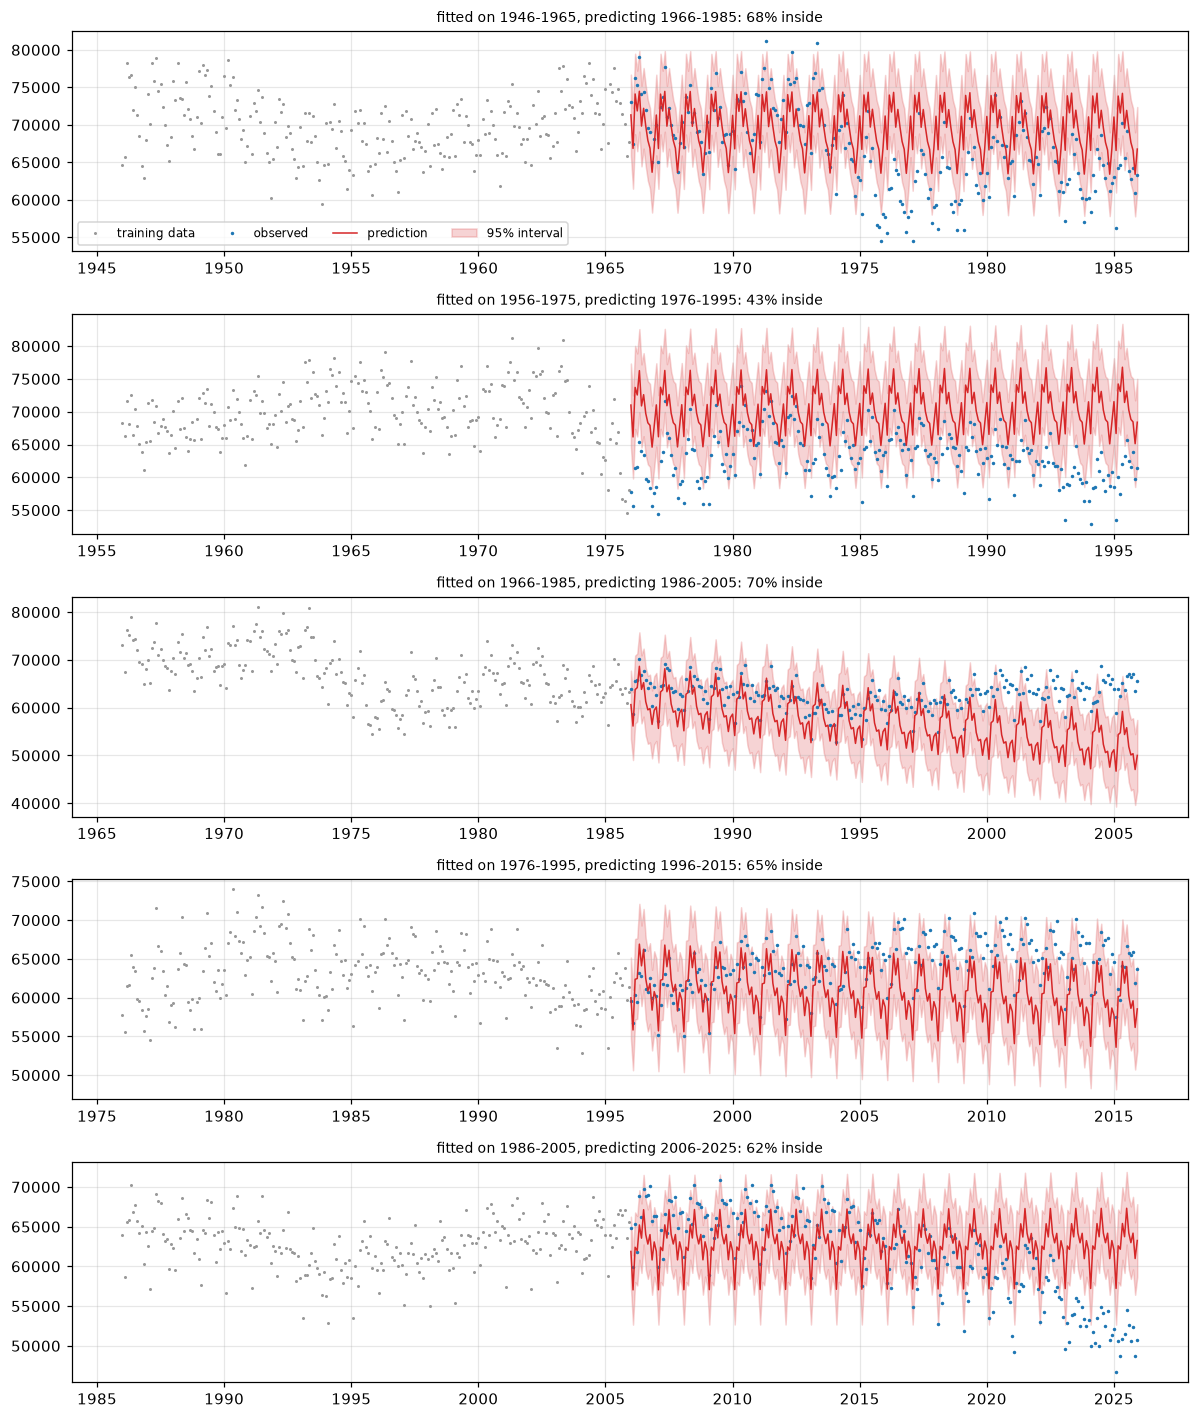

1946-1965 -> 1966-1985    67.9%
1956-1975 -> 1976-1995    42.9%
1966-1985 -> 1986-2005    70.0%
1976-1995 -> 1996-2015    65.0%
1986-2005 -> 2006-2025    62.1%
Name: empirical coverage, dtype: str

In [38]:
def prediction_band(fit, horizon, alpha=ALPHA):
    n, p = fit["n"], fit["p"]
    Z0 = design_matrix(np.arange(n + 1, n + horizon + 1))
    centre = Z0 @ fit["beta"]
    leverage = np.einsum("ij,jk,ik->i", Z0, fit["gram_inv"], Z0)
    half = stats.t.ppf(1 - alpha / 2, n - p) * np.sqrt(fit["sigma2"] * (1 + leverage))
    return centre, half


predictable = [s for s in windows if s + 39 <= 2025]
coverage = {}

fig, axes = plt.subplots(len(predictable), 1, figsize=(11, 2.6 * len(predictable)))
for ax, start in zip(axes, predictable):
    fit = windows[start]
    centre, half = prediction_band(fit, N_WINDOW)
    offset = (start - 1946 + 20) * PERIOD
    future = values[offset:offset + N_WINDOW]
    inside = (future >= centre - half) & (future <= centre + half)
    coverage[f"{start}-{start + 19} -> {start + 20}-{start + 39}"] = inside.mean()

    t_fit = start + np.arange(N_WINDOW) / PERIOD
    t_new = start + 20 + np.arange(N_WINDOW) / PERIOD
    ax.plot(t_fit, fit["x"], ".", ms=2, color="0.6", label="training data")
    ax.plot(t_new, future, ".", ms=2.5, color="C0", label="observed")
    ax.plot(t_new, centre, color="C3", lw=1, label="prediction")
    ax.fill_between(t_new, centre - half, centre + half, color="C3", alpha=0.2, label="95% interval")
    ax.set_title(f"fitted on {start}-{start + 19}, predicting {start + 20}-{start + 39}: "
                 f"{inside.mean():.0%} inside", fontsize=9)
axes[0].legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.show()

pd.Series(coverage, name="empirical coverage").map("{:.1%}".format)

## 6. testing seasonality hypothesis on 2006–2025

**Are April and June equivalent?** Both have 30 days, so their totals are comparable without a
calendar correction. With $x = e_{s_4} - e_{s_6}$, test $H_0: x^\top\beta = 0$.

In [41]:
fit = windows[2006]
n, p, gram_inv, sigma2 = fit["n"], fit["p"], fit["gram_inv"], fit["sigma2"]

contrast = np.zeros(p)
contrast[2 + 3] = 1.0      # s_4
contrast[2 + 5] = -1.0     # s_6
t_stat = contrast @ fit["beta"] / np.sqrt(sigma2 * contrast @ gram_inv @ contrast)
p_value_t = 2 * stats.t.sf(abs(t_stat), n - p)
print(f"April - June  : estimate = {contrast @ fit['beta']:,.0f} births per month")
print(f"                t = {t_stat:.3f}, critical value = {stats.t.ppf(1 - ALPHA / 2, n - p):.3f}, "
      f"p-value = {p_value_t:.3g}")

April - June  : estimate = -3,083 births per month
                t = -4.669, critical value = 1.970, p-value = 5.19e-06


$p<0.01$ Null hypothesis is rejected; April and June cannot be considered equivalent.

**Is there any seasonality?** Test $H_0: s_1 = \dots = s_{11} = 0$, which by the sum constraint also
forces $s_{12} = 0$. Here $A = [\,0_{11\times 2} \mid I_{11}\,]$, $r = 11$, and the Fisher statistic
applies. As a check, the same statistic is recomputed from the residual sums of squares of the nested
and full models.

In [42]:

r = PERIOD - 1
A = np.hstack([np.zeros((r, 2)), np.eye(r)])
A_beta = A @ fit["beta"]
f_stat = A_beta @ np.linalg.solve(A @ gram_inv @ A.T, A_beta) / (r * sigma2)
p_value_f = stats.f.sf(f_stat, r, n - p)
print(f"\nseasonality   : F = {f_stat:.2f}, critical value = {stats.f.ppf(1 - ALPHA, r, n - p):.3f}, "
      f"p-value = {p_value_f:.3g}")

Z_trend = fit["Z"][:, :2]
res_restricted = fit["x"] - Z_trend @ np.linalg.lstsq(Z_trend, fit["x"], rcond=None)[0]
f_from_rss = ((res_restricted @ res_restricted - fit["residuals"] @ fit["residuals"]) / r) / sigma2
print(f"                cross-check from residual sums of squares: F = {f_from_rss:.2f}")


seasonality   : F = 34.89, critical value = 1.831, p-value = 7.72e-43
                cross-check from residual sums of squares: F = 34.89


$p= 0$. Null hypothesis is rejected and there's obviously seasonal effect.

## 7. Homoskedasticity and Gaussian error assumptions

The laws above need independent, homoscedastic, Gaussian errors. We use lag-1 autocorrelation of the residuals to check if residuals are truly independent variables.

In [40]:
diagnostics = pd.DataFrame(
    {f"{start}-{start + 19}": {
        "lag-1 autocorrelation": np.corrcoef(f["residuals"][:-1], f["residuals"][1:])[0, 1],
        "sigma_hat": np.sqrt(f["sigma2"])}
     for start, f in windows.items()}).T
diagnostics.round(3)

,lag-1 autocorrelation,sigma_hat
1946-1965,0.839,2642.317
1956-1975,0.888,3113.660
1966-1985,0.928,3496.728
1976-1995,0.862,2558.335
1986-2005,0.804,2152.962
1996-2015,0.700,1673.117
2006-2025,0.827,2088.325


The residuals are not independent. Lag-1 autocorrelation runs from 0.70 to 0.93 across the seven
windows, and under independence with n = 240 this statistic should sit near zero with a standard
error around $1/\sqrt{240}=0.065$. These values are $14 \times$ standard errors out.

## Conclusions and possible extensions

- A month-of-year effect that is large, sharply estimated, and easily visible against the noise.
- A seasonal shape that has drifted over the decades, which is why the model is fitted locally.